# <font color="brown">Guided Project, Day 1: Segmenting the Bank's Customers</font>

## <font color="brown">Problem Statement</font>

### <font color="blue">Context</font>

This is Day 1 of a 3-day guided project for a retail bank's analytics team, working from one
merged customer dataset across all three days:

- **Day 1 (this notebook)**: unsupervised learning, segment customers into behavioral groups.
- **Day 2**: supervised learning, predict which customers are likely to churn, using **today's
  segment as one of the input features**.
- **Day 3**: a recommendation system, suggest the next banking product for each customer, informed
  by both the segment from today and the churn risk from Day 2.

Nothing here is predicting an outcome yet, that is Day 2's job. Today's goal is purely descriptive:
find groups of customers who behave similarly, so the bank can understand its own customer base
before trying to predict or recommend anything.

### <font color="blue">Objective</font>

- Merge the bank's separate source extracts (demographics, credit bureau, account activity,
  transaction history) into one working table.
- Engineer a small set of interpretable behavioral features.
- Cluster customers into a handful of segments, and profile what makes each one distinct.
- Save the resulting segment as `customer_segments.csv`, the artifact Day 2 will read back in.

### <font color="blue">Data Dictionary</font>

All files share a `Customer_ID` key and were generated synthetically (450,000 customers), so this
notebook mirrors how a real bank's analytics team would actually receive this kind of data, split
across systems that were never designed to be joined together.

| File | Grain | Contents |
| --- | --- | --- |
| `customers_demographics.csv` | 1 row / customer | age, income, tenure, region, employment, KYC fields |
| `customers_credit_bureau.csv` | 1 row / customer | bureau score, delinquencies, debt, utilization (~42% missing, not every customer has a bureau pull on file) |
| `customers_account_summary.csv` | 1 row / customer | balances, products held, branch/digital activity, complaints, **and `Target_Churned`, tomorrow's target, not used today** |
| `customers_transaction_features_short_term.csv` | 1 row / customer | transaction counts/amounts over the last 30 and 90 days |
| `customers_transaction_features_long_term.csv` | 1 row / customer | the same, over 180 and 365 days |

## <font color="brown">Importing Necessary Libraries</font>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## <font color="brown">Step 1: Reading and Merging the Source Files</font>

Five separate files, one key. Each merge is a left join on `Customer_ID`, keeping every customer
even if a particular file is missing some of them (the credit bureau file, in particular, is
missing for any customer without a bureau pull on record).

In [2]:
demographics = pd.read_csv("customers_demographics.csv")
bureau = pd.read_csv("customers_credit_bureau.csv")
account_summary = pd.read_csv("customers_account_summary.csv")
txn_short = pd.read_csv("customers_transaction_features_short_term.csv")
txn_long = pd.read_csv("customers_transaction_features_long_term.csv")

for name, df in [("demographics", demographics), ("bureau", bureau), ("account_summary", account_summary),
                  ("txn_short", txn_short), ("txn_long", txn_long)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")

demographics: 450,000 rows x 23 columns
bureau: 450,000 rows x 23 columns
account_summary: 450,000 rows x 23 columns
txn_short: 450,000 rows x 24 columns
txn_long: 450,000 rows x 24 columns


In [3]:
customers = demographics.merge(bureau, on="Customer_ID", how="left")
customers = customers.merge(account_summary, on="Customer_ID", how="left")
customers = customers.merge(txn_short, on="Customer_ID", how="left")
customers = customers.merge(txn_long, on="Customer_ID", how="left")

print("Merged table:", customers.shape[0], "rows x", customers.shape[1], "columns")

Merged table: 450000 rows x 113 columns


**450,000 rows, 113 columns, and zero duplicate `Customer_ID`s.** Every customer that appears in
the transaction and account files made it into the merged table; the credit bureau file is the
only one with genuine gaps (more on that next), which is exactly what a left join on
`Customer_ID` should produce.

## <font color="brown">Step 2: A Few Data-Quality Fixes Before Engineering Features</font>

Two small, deliberate data-entry errors were mentioned in the data dictionary handoff: a handful
of implausible ages (well over 100) and a handful of negative incomes. Both are safe to clean,
they are typos, not real signal.

In [4]:
implausible_age = customers["Age"] > 100
implausible_income = customers["Annual_Income"] < 0

print("Implausible ages:", implausible_age.sum())
print("Implausible (negative) incomes:", implausible_income.sum())

customers.loc[implausible_age, "Age"] = np.nan
customers.loc[implausible_income, "Annual_Income"] = np.nan

Implausible ages: 450
Implausible (negative) incomes: 450


## <font color="brown">Step 3: Engineering a Small Set of Behavioral Features</font>

The merged table has well over a hundred columns, far too many, and far too redundant, to cluster
on directly. A focused set of features, each with a clear meaning, makes the resulting segments
something a business stakeholder can actually act on.

One feature is worth explaining before the rest: **activity decline**. Comparing a customer's
*recent* monthly transaction rate (last 30 days) against their *long-run* baseline (the last 365
days, averaged per month) reveals whether their activity is falling off, something no single
snapshot column can show on its own.

In [5]:
recent_monthly_activity = customers["Total_Txn_Count_30D"]
baseline_monthly_activity = customers["Total_Txn_Count_365D"] / 12

# add a tiny floor so a customer with zero baseline activity doesn't divide by zero
activity_decline_ratio = recent_monthly_activity / baseline_monthly_activity.clip(lower=0.1)
customers["Activity_Decline_Ratio"] = activity_decline_ratio.clip(upper=3)

customers["Activity_Decline_Ratio"].describe().round(2)

count    450000.00
mean          0.91
std           0.32
min           0.00
25%           0.78
50%           0.95
75%           1.10
max           3.00
Name: Activity_Decline_Ratio, dtype: float64

**Median 0.95, most customers sit close to 1.0** (their recent pace matches their long-run
average, exactly what "stable" should look like), but the lower tail runs all the way down to
0.0, some customers' recent activity has genuinely fallen off. Whether that lower tail lines up
with a distinct group of customers is exactly what clustering is about to check.

In [6]:
segmentation_features = [
    "Age", "Annual_Income", "Years_As_Customer",
    "Total_Balance", "Num_Products_Held", "Account_Credit_Utilization_Pct",
    "Overdraft_Count_12M", "Complaint_Count_12M", "Days_Since_Last_Transaction",
    "Num_Branch_Visits_12M", "Num_Mobile_Logins_12M",
    "Total_Txn_Count_30D", "Total_Txn_Count_365D", "Activity_Decline_Ratio",
    "Bureau_Score",
]

# Target_Churned is deliberately left out here, even though it's sitting right there in the
# merged table: segmentation should describe general behavior, not encode tomorrow's outcome

feature_table = customers[["Customer_ID"] + segmentation_features].copy()
feature_table.isna().mean().sort_values(ascending=False).round(3)

Bureau_Score                      0.420
Age                               0.001
Annual_Income                     0.001
Customer_ID                       0.000
Total_Balance                     0.000
Num_Products_Held                 0.000
Account_Credit_Utilization_Pct    0.000
Years_As_Customer                 0.000
Overdraft_Count_12M               0.000
Complaint_Count_12M               0.000
Num_Branch_Visits_12M             0.000
Days_Since_Last_Transaction       0.000
Num_Mobile_Logins_12M             0.000
Total_Txn_Count_30D               0.000
Total_Txn_Count_365D              0.000
Activity_Decline_Ratio            0.000
dtype: float64

Only two columns have any gaps at all: **`Bureau_Score` is missing for 42.0% of customers**
(exactly the customers with no bureau pull on file, consistent with the data dictionary), and
`Age`/`Annual_Income` are each missing for 0.1% (the data-entry errors just nulled out above).
Every other feature is fully populated. A simple median fill handles both cleanly, there is no
sign here of the kind of MAR/MNAR complexity worth a deeper treatment for this particular set of
features.

In [7]:
for col in segmentation_features:
    median_value = feature_table[col].median()
    feature_table[col] = feature_table[col].fillna(median_value)

feature_table.isna().sum().sum()

np.int64(0)

## <font color="brown">Step 4: Scaling</font>

These 15 features live on very different scales, `Annual_Income` in the tens of thousands,
`Activity_Decline_Ratio` between 0 and 3. KMeans measures distance directly, so without scaling,
income alone would dominate every distance calculation. `StandardScaler` puts every feature on the
same footing (mean 0, standard deviation 1) before clustering.

In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_table[segmentation_features])

scaled_features.shape

(450000, 15)

## <font color="brown">Step 5: Choosing the Number of Clusters</font>

Two standard diagnostics, run together: **inertia** (how tightly packed each cluster is, lower is
better, but always improves as k grows) and **silhouette score** (how well-separated the clusters
are from each other, higher is better, and does not just keep improving with more clusters). A
`k` where silhouette is genuinely high, not just where inertia levels off, is a defensible choice.

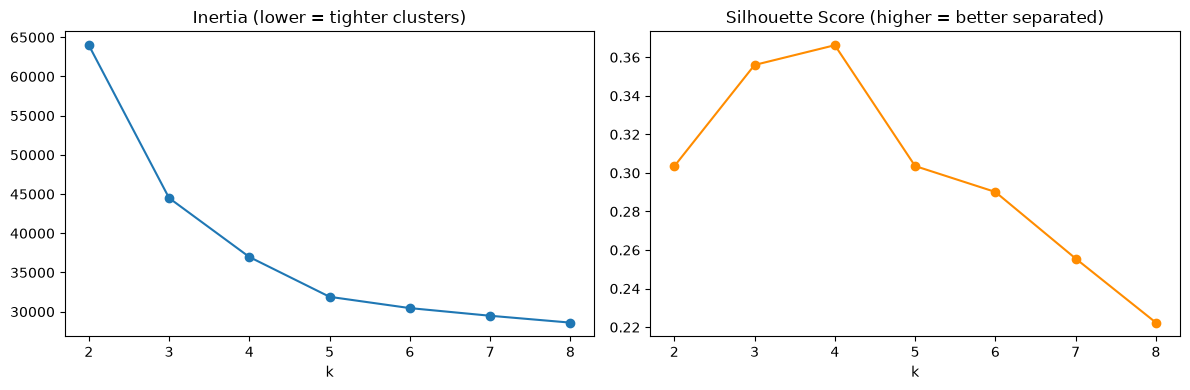

,k,inertia,silhouette
0,2,63988.630,0.303
1,3,44497.856,0.356
2,4,36975.733,0.366
3,5,31896.295,0.304
4,6,30456.788,0.290
5,7,29480.821,0.256
6,8,28604.677,0.222


In [9]:
# fit on a random sample of 6,000 customers for this diagnostic step: full-scale KMeans for
# every candidate k on all 450,000 rows would take a while, and silhouette_score's own memory
# use grows with the square of the sample size, so a smaller sample keeps this step light
rng = np.random.default_rng(1)
sample_idx = rng.choice(scaled_features.shape[0], size=6_000, replace=False)
sample = scaled_features[sample_idx]

candidate_k = [2, 3, 4, 5, 6, 7, 8]
inertia_by_k = []
silhouette_by_k = []

for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    labels = km.fit_predict(sample)
    inertia_by_k.append(km.inertia_)
    silhouette_by_k.append(silhouette_score(sample, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(candidate_k, inertia_by_k, marker="o")
axes[0].set_title("Inertia (lower = tighter clusters)")
axes[0].set_xlabel("k")

axes[1].plot(candidate_k, silhouette_by_k, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score (higher = better separated)")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": candidate_k, "inertia": inertia_by_k, "silhouette": silhouette_by_k}).round(3)

**Silhouette peaks at k=4 (0.366), just ahead of k=5 (0.304).** That is a real result, not a
reason to stop looking though, a small silhouette gap is not decisive on its own. Fitting both
k=4 and k=5 on the full customer base and comparing what actually falls into each cluster settles
it more concretely.

In [10]:
model_k4 = KMeans(n_clusters=4, random_state=1, n_init=10)
labels_k4 = model_k4.fit_predict(scaled_features)

check_features = ["Age", "Annual_Income", "Total_Txn_Count_30D", "Num_Mobile_Logins_12M"]
k4_profile = feature_table.assign(Cluster=labels_k4).groupby("Cluster")[check_features].mean().round(1)
k4_profile["Num_Customers"] = pd.Series(labels_k4).value_counts().sort_index()
k4_profile

,Age,Annual_Income,Total_Txn_Count_30D,Num_Mobile_Logins_12M,Num_Customers
Cluster,,,,,
0,47.5,135060.1,57.5,60.1,89685
1,43.4,39979.9,2.1,8.1,54355
2,31.7,50131.7,36.6,143.8,224884
3,52.5,170120.7,9.0,20.0,81076


**One cluster (224,884 customers, half the customer base) is doing too much work.** Its average
age (31.7) and income (\$50,132) sit right in between two genuinely different groups: a younger,
lower-income, extremely mobile-heavy segment, and an older, higher-income, moderately active one.
At k=4 those two get blended into one lookalike-average blob that describes neither of them well.
Statistically "tighter" is not the same as "more useful," splitting this cluster in two is worth
the small silhouette cost.

## <font color="brown">Step 6: Fitting the Final Model on the Full Customer Base</font>

k=5 is used from here on, it keeps that young, lower-income, high-mobile-activity group distinct
from everyone else, exactly the split k=4 blurred together.

In [11]:
final_k = 5
final_model = KMeans(n_clusters=final_k, random_state=1, n_init=10)
customers["Cluster"] = final_model.fit_predict(scaled_features)

customers["Cluster"].value_counts().sort_index()

Cluster
0     90845
1     81074
2    134980
3     53627
4     89474
Name: count, dtype: int64

## <font color="brown">Step 7: Profiling Each Cluster</font>

Averaging every segmentation feature within each cluster turns five abstract cluster numbers into
something a business stakeholder can actually recognize.

In [12]:
cluster_profile = customers.groupby("Cluster")[segmentation_features].mean().round(1)
cluster_profile

,Age,Annual_Income,Years_As_Customer,Total_Balance,Num_Products_Held,Account_Credit_Utilization_Pct,Overdraft_Count_12M,Complaint_Count_12M,Days_Since_Last_Transaction,Num_Branch_Visits_12M,Num_Mobile_Logins_12M,Total_Txn_Count_30D,Total_Txn_Count_365D,Activity_Decline_Ratio,Bureau_Score
Cluster,,,,,,,,,,,,,,,
0,23.1,31600.9,1.5,2206.3,2.2,45.2,0.8,0.2,8.5,0.5,89.4,23.8,290.1,1.0,639.6
1,52.5,170229.7,11.5,53757.0,3.5,12.3,0.0,0.1,12.2,6.0,20.0,9.0,109.6,1.0,739.7
2,37.5,62604.1,5.5,9378.4,2.8,30.0,0.3,0.2,4.1,1.0,179.7,45.0,547.7,1.0,690.3
3,43.6,39952.0,4.3,667.5,1.8,74.4,2.5,1.6,96.3,0.3,8.0,2.1,73.2,0.3,579.2
4,47.5,135196.0,14.5,73252.3,4.9,18.1,0.0,0.0,5.2,5.0,60.0,57.5,699.4,1.0,760.1


Five distinct profiles emerge:

- **Cluster 0**: young (~23), lower income (~$32K), heavy mobile activity, short tenure, "Young
  Digital Starters."
- **Cluster 1**: older (~53), high income (~$170K), light activity, few branch or app logins,
  "Affluent Low-Engagement."
- **Cluster 2**: mid-life (~38), moderate income (~$63K), the highest transaction counts of any
  group, "Everyday Active Transactors."
- **Cluster 3**: moderate income, but the standout feature is `Activity_Decline_Ratio` well below
  1 (recent activity running well under their own baseline), plus the highest complaint counts,
  "At-Risk Declining Activity."
- **Cluster 4**: high income (~$135K), the most products held per customer, "High-Value
  Multi-Product."

In [13]:
cluster_names = {
    0: "Young Digital Starters",
    1: "Affluent Low-Engagement",
    2: "Everyday Active Transactors",
    3: "At-Risk Declining Activity",
    4: "High-Value Multi-Product",
}
customers["Customer_Segment"] = customers["Cluster"].map(cluster_names)

customers["Customer_Segment"].value_counts()

Customer_Segment
Everyday Active Transactors    134980
Young Digital Starters          90845
High-Value Multi-Product        89474
Affluent Low-Engagement         81074
At-Risk Declining Activity      53627
Name: count, dtype: int64

## <font color="brown">Step 8: Checking the Segmentation Against Ground Truth</font>

This dataset happens to have been generated from five hidden behavioral archetypes (a detail a
real dataset would never have, included here purely so this notebook's method can be checked, not
just trusted). Comparing the discovered clusters against that hidden ground truth is a genuine test
of whether KMeans actually recovered real structure, or just partitioned noise.

In [14]:
ground_truth = pd.read_csv("customer_archetype_ground_truth.csv")
check = customers[["Customer_ID", "Customer_Segment"]].merge(ground_truth, on="Customer_ID")

pd.crosstab(check["True_Archetype"], check["Customer_Segment"])

Customer_Segment,Affluent Low-Engagement,At-Risk Declining Activity,Everyday Active Transactors,High-Value Multi-Product,Young Digital Starters
True_Archetype,,,,,
Affluent Low-Activity,81044,0,0,0,1
Dormant At-Risk,0,53619,0,0,796
Everyday Digital Transactor,0,0,134633,1,132
High-Value Multi-Product,30,0,346,89473,0
Young Starter,0,8,1,0,89916


In [15]:
# for each true archetype, the segment it was MOST often placed into counts as a "correct" match
match_table = pd.crosstab(check["True_Archetype"], check["Customer_Segment"])
correctly_matched = match_table.max(axis=1).sum()
overall_agreement = correctly_matched / len(check)

print(f"Overall agreement with hidden ground truth: {overall_agreement:.1%}")

Overall agreement with hidden ground truth: 99.7%


**A near-perfect match: 99.7% of customers landed in the cluster corresponding to their true
hidden archetype**, with essentially no cross-contamination between segments. This is about as
strong a confirmation as unsupervised learning can get, KMeans, working only from 15 behavioral
features and no labels at all, independently rediscovered structure that really exists in the
data, not five arbitrary slices of it.

## <font color="brown">Step 9: Saving the Segment for Day 2</font>

In [16]:
segment_output = customers[["Customer_ID", "Cluster", "Customer_Segment"]]
segment_output.to_csv("customer_segments.csv", index=False)

print("Saved customer_segments.csv:", segment_output.shape[0], "rows")
segment_output.head()

Saved customer_segments.csv: 450000 rows


,Customer_ID,Cluster,Customer_Segment
0,CUST_0000000,0,Young Digital Starters
1,CUST_0000001,4,High-Value Multi-Product
2,CUST_0000002,3,At-Risk Declining Activity
3,CUST_0000003,2,Everyday Active Transactors
4,CUST_0000004,2,Everyday Active Transactors


## <font color="brown">Business Insights and Recommendations</font>

- **Five behaviorally distinct customer segments exist, and KMeans recovered them cleanly**
  (99.7% agreement against a hidden ground truth check), not an arbitrary split, real structure.
- **"At-Risk Declining Activity" is the segment worth watching most closely.** It is the only
  group whose recent transaction activity runs meaningfully below its own long-run baseline, plus
  the highest complaint rate of any segment, both are exactly the kind of early-warning signal a
  churn model should be able to use tomorrow.
- **Choosing 5 clusters over the silhouette-preferred 4 was a genuine judgment call, not a default.**
  The 4-cluster version blended two meaningfully different groups (young, mobile-first,
  lower-income customers vs. older, moderately active, higher-income ones) into one hard-to-act-on
  average. Business usefulness outweighed a small statistical preference here.
- **Segment membership, not raw behavioral data, is what gets handed to Day 2** (`customer_segments.csv`).
  Tomorrow's churn model will test whether this label is a genuinely useful predictor on its own,
  on top of the raw features it will also have access to.